# 01 · CNLM-Langevin — Solving SAT & MaxSAT

The **CNLM-Langevin** solver reformulates a discrete SAT/MaxSAT problem as a *continuous*
optimization on a manifold and then runs a **fast–slow stochastic differential equation
(SDE)** — an annealed Langevin dynamics — to roll the system into a satisfying assignment.

Intuitively:

* every Boolean variable $x_i \in \{0,1\}$ is relaxed to a continuous coordinate
  $z_i \in \mathbb{R}$, decoded with a sigmoid $x_i = \sigma(z_i)$;
* a **free energy** combines a smooth clause-violation potential with an inverse-temperature
  $\beta(t)$ (the *fast* schedule) and a confidence/sharpness $c(t)$ (the *slow* schedule);
* many **chains** (walkers) explore in parallel; the best one wins.

This notebook covers:

1. Loading a DIMACS `.cnf` and the one-liner solve.
2. What lives inside a `SolveResult`.
3. The `SolverConfig` knobs that matter.
4. **Convergence diagnostics** — plotting the schedules and the satisfied-clause curve.
5. Driving the solver object directly + comparing chain counts.
6. **MaxSAT** on a weighted `.wcnf`.

Everything runs in seconds on CPU.

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pycnlm
from pycnlm import (
    SolverConfig, SolveResult, CNLMLangevinSolver,
    solve_sat_file, solve_maxsat_file,
)

DATA = Path("data")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("pycnlm", pycnlm.__version__, "ready")

pycnlm 0.1.0 ready


## 1. The one-liner: `solve_sat_file`

The fastest path. Give it a path and (optionally) a `SolverConfig`; get back a `SolveResult`.

In [2]:
cfg = SolverConfig(
    n_steps=800,      # Euler–Maruyama integration steps
    n_chains=24,      # parallel walkers
    seed=7,
)
res = solve_sat_file(DATA / "sample_3sat.cnf", cfg)

print(f"instance      : {res.instance_name}")
print(f"variables     : {res.n_vars}")
print(f"clauses       : {res.n_clauses}")
print(f"SATISFIED?    : {res.is_SAT}")
print(f"satisfied     : {res.n_satisfied}/{res.n_clauses}  (score={res.sat_score:.3f})")
print(f"best chain     : #{res.best_chain} of {res.n_chains}")
print(f"converged step : {res.converged_step}")
print(f"runtime        : {res.runtime_s*1000:.1f} ms")

instance      : sample_3sat.cnf
variables     : 6
clauses       : 8
SATISFIED?    : True
satisfied     : 8/8  (score=1.000)
best chain     : #3 of 24
converged step : 0
runtime        : 0.9 ms


## 2. Anatomy of a `SolveResult`

It is a dataclass holding both the **answer** and a full **trace** for diagnostics.

In [3]:
import dataclasses

groups = {
    "answer":   ["assignment", "is_SAT", "n_satisfied", "n_clauses", "sat_score"],
    "maxsat":   ["cost", "n_hard_sat", "n_hard_total", "n_soft_sat", "n_soft_total"],
    "run meta": ["best_chain", "n_chains", "n_steps", "runtime_s", "converged_step"],
    "history":  [f.name for f in dataclasses.fields(res) if f.name.startswith("history_")],
}
for g, names in groups.items():
    print(f"[{g}]")
    for n in names:
        print(f"    {n}")
    print()

[answer]
    assignment
    is_SAT
    n_satisfied
    n_clauses
    sat_score

[maxsat]
    cost
    n_hard_sat
    n_hard_total
    n_soft_sat
    n_soft_total

[run meta]
    best_chain
    n_chains
    n_steps
    runtime_s
    converged_step

[history]
    history_steps
    history_beta
    history_c_mean
    history_c_min
    history_c_max
    history_free_energy
    history_n_sat
    history_best_n_sat
    history_x



In [4]:
# The decoded assignment is a NumPy boolean/int array, one entry per variable.
print("assignment (var -> value):")
for i, b in enumerate(res.assignment, start=1):
    print(f"  x{i} = {int(b)}")

assignment (var -> value):
  x1 = 0
  x2 = 0
  x3 = 0
  x4 = 0
  x5 = 0
  x6 = 1


## 3. The knobs: `SolverConfig`

The defaults are sensible. The fields you will reach for most often:

| field | meaning |
|-------|---------|
| `n_steps` | number of SDE integration steps (more = more thorough, slower) |
| `n_chains` | parallel walkers; the best chain is returned |
| `dt` | integration time-step $\Delta t$ |
| `eps` | margin $\varepsilon\in(0,1)$ in the smoothed-DNF clause potential |
| `beta_init`,`beta_final`,`beta_schedule` | inverse-temperature anneal (fast) |
| `c_init`,`c_final`,`c_schedule` | confidence / sharpness anneal (slow) |
| `use_slow_sde`,`eta`,`beta_c` | turn the confidence into its own noisy SDE |
| `early_stop_when_sat` | stop the moment a chain is fully SAT |
| `seed` | reproducibility |

Print every field with its default:

In [5]:
for f in dataclasses.fields(SolverConfig):
    print(f"  {f.name:24s} = {f.default}")

  n_steps                  = 1500
  dt                       = 0.05
  n_chains                 = 16
  seed                     = None
  eps                      = 0.5
  lam                      = 0.001
  z_init_scale             = 0.5
  z_clip                   = 30.0
  beta_init                = 1.0
  beta_final               = 80.0
  beta_schedule            = log
  beta_poly_p              = 1.0
  c_init                   = 1.0
  c_final                  = 60.0
  c_schedule               = lin
  c_poly_p                 = 1.5
  use_slow_sde             = False
  eta                      = 0.05
  beta_c                   = 50.0
  c_min                    = 0.01
  c_max                    = 1000.0
  restart_on_stuck         = True
  stuck_patience           = 200
  early_stop_when_sat      = True
  record_history_every     = 1
  record_assignment_every  = 0
  verbose                  = False
  hard_scale               = 1000.0


## 4. Convergence diagnostics

To *see* the dynamics we want the full history, so we disable early stopping and record
every step. We then plot:

* the **β(t)** (fast) and **c(t)** (slow) schedules,
* the **free energy** of the best chain,
* the **#satisfied clauses** — both the current best chain and the running best.

In [6]:
diag_cfg = SolverConfig(
    n_steps=1200,
    n_chains=24,
    seed=7,
    early_stop_when_sat=False,   # keep integrating so the history is full
    record_history_every=1,      # log every step
)
res_d = solve_sat_file(DATA / "sample_3sat.cnf", diag_cfg)
print("history length:", len(res_d.history_steps), "steps logged")
print("final best #SAT:", int(np.max(res_d.history_best_n_sat)), "/", res_d.n_clauses)

history length: 1200 steps logged
final best #SAT: 8 / 8


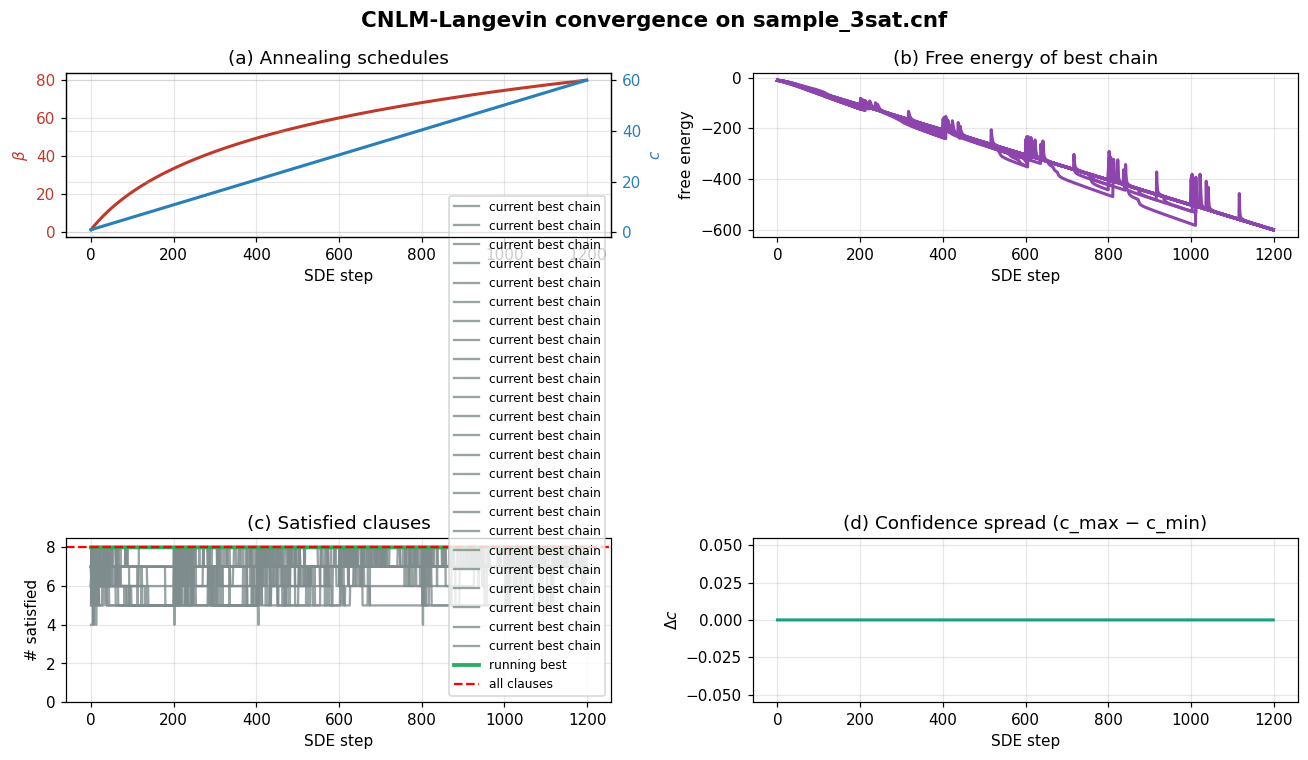

In [7]:
steps = np.asarray(res_d.history_steps)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("CNLM-Langevin convergence on sample_3sat.cnf", fontsize=14, fontweight="bold")

# (a) annealing schedules
ax = axes[0, 0]
ax.plot(steps, res_d.history_beta, color="#c0392b", lw=2, label=r"$\beta(t)$ (fast)")
ax.set_ylabel(r"$\beta$", color="#c0392b")
ax.tick_params(axis="y", labelcolor="#c0392b")
ax2 = ax.twinx()
ax2.plot(steps, res_d.history_c_mean, color="#2980b9", lw=2, label=r"$c(t)$ (slow, mean)")
ax2.fill_between(steps, res_d.history_c_min, res_d.history_c_max, color="#2980b9", alpha=0.15)
ax2.set_ylabel(r"$c$", color="#2980b9")
ax2.tick_params(axis="y", labelcolor="#2980b9")
ax.set_title("(a) Annealing schedules")
ax.set_xlabel("SDE step")

# (b) free energy
ax = axes[0, 1]
ax.plot(steps, res_d.history_free_energy, color="#8e44ad", lw=2)
ax.set_title("(b) Free energy of best chain")
ax.set_xlabel("SDE step"); ax.set_ylabel("free energy")

# (c) satisfied clauses
ax = axes[1, 0]
ax.plot(steps, res_d.history_n_sat, color="#7f8c8d", lw=1.5, alpha=0.8, label="current best chain")
ax.plot(steps, res_d.history_best_n_sat, color="#27ae60", lw=2.5, label="running best")
ax.axhline(res_d.n_clauses, color="red", ls="--", lw=1.5, label="all clauses")
ax.set_ylim(0, res_d.n_clauses + 0.5)
ax.set_title("(c) Satisfied clauses")
ax.set_xlabel("SDE step"); ax.set_ylabel("# satisfied"); ax.legend(loc="lower right", fontsize=8)

# (d) confidence band width (slow-mode spread across chains)
ax = axes[1, 1]
ax.plot(steps, np.asarray(res_d.history_c_max) - np.asarray(res_d.history_c_min),
        color="#16a085", lw=2)
ax.set_title("(d) Confidence spread (c_max − c_min)")
ax.set_xlabel("SDE step"); ax.set_ylabel(r"$\Delta c$")

plt.tight_layout()
plt.show()

Reading the plots:

* **(a)** β rises (cooling) while c sharpens the decoder — the *fast–slow* interplay.
* **(b)** the free energy descends as the system commits to an assignment.
* **(c)** the **running-best** curve climbs to the dashed line (all clauses satisfied).
* **(d)** the spread of c across chains shows how the walkers diversify then agree.

## 5. Driving the solver object + a chain-count study

`solve_sat_file` is a convenience wrapper around `CNLMLangevinSolver`. Using the object
directly lets you reuse a parsed instance. Here we sweep `n_chains` to show the classic
*more walkers → more reliable* trade-off (averaged over seeds).

In [8]:
from pycnlm.langevin import parse_dimacs_cnf
from pycnlm.langevin import SATInstance as LangevinSATInstance

parsed = parse_dimacs_cnf(DATA / "sample_3sat.cnf")
instance = LangevinSATInstance.from_parsed(parsed, name="sample_3sat")
print("parsed instance:", instance.name, "| n_vars =", instance.n_vars,
      "| n_clauses =", instance.n_clauses)

parsed instance: sample_3sat | n_vars = 6 | n_clauses = 8


In [9]:
chain_counts = [1, 2, 4, 8, 16, 32]
seeds = range(6)
success_rate, mean_ms = [], []

for nc in chain_counts:
    succ, times = 0, []
    for s in seeds:
        cfg_s = SolverConfig(n_steps=500, n_chains=nc, seed=s)
        r = CNLMLangevinSolver(instance, cfg_s).solve()
        succ += int(r.is_SAT)
        times.append(r.runtime_s * 1000)
    success_rate.append(100 * succ / len(seeds))
    mean_ms.append(np.mean(times))
    print(f"  n_chains={nc:2d} -> success {success_rate[-1]:5.1f}%  "
          f"mean {mean_ms[-1]:6.1f} ms")

  n_chains= 1 -> success 100.0%  mean    3.6 ms
  n_chains= 2 -> success 100.0%  mean    0.3 ms
  n_chains= 4 -> success 100.0%  mean    0.2 ms
  n_chains= 8 -> success 100.0%  mean    0.2 ms
  n_chains=16 -> success 100.0%  mean    0.2 ms
  n_chains=32 -> success 100.0%  mean    0.2 ms


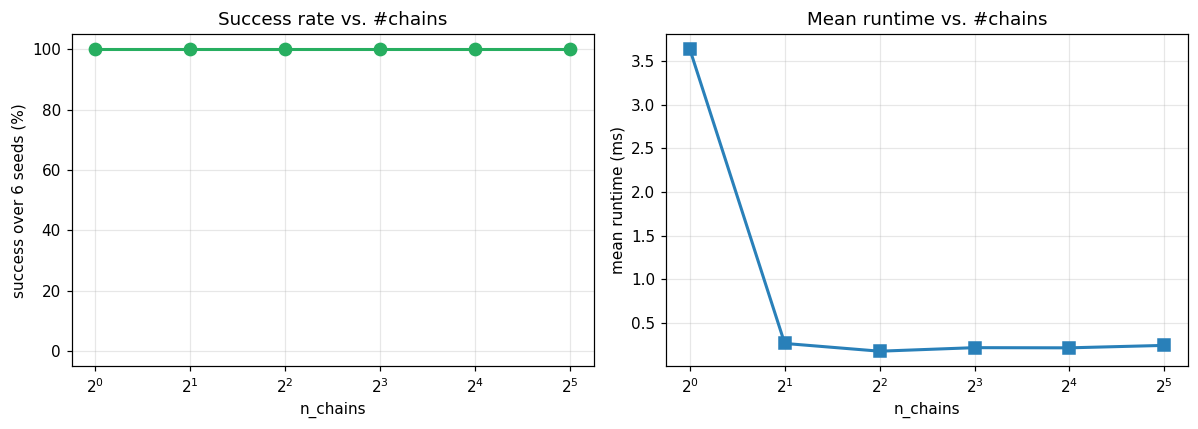

In [10]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
axL.plot(chain_counts, success_rate, "o-", color="#27ae60", lw=2, ms=8)
axL.set_xscale("log", base=2)
axL.set_title("Success rate vs. #chains")
axL.set_xlabel("n_chains"); axL.set_ylabel("success over 6 seeds (%)")
axL.set_ylim(-5, 105)

axR.plot(chain_counts, mean_ms, "s-", color="#2980b9", lw=2, ms=8)
axR.set_xscale("log", base=2)
axR.set_title("Mean runtime vs. #chains")
axR.set_xlabel("n_chains"); axR.set_ylabel("mean runtime (ms)")
plt.tight_layout(); plt.show()

## 6. MaxSAT on a weighted `.wcnf`

For **MaxSAT** we minimise the total weight of *violated soft* clauses while keeping all
*hard* clauses satisfied. The API mirrors SAT but the result carries cost / hard / soft
fields.

In [11]:
mcfg = SolverConfig(n_steps=1000, n_chains=24, seed=3)
mres = solve_maxsat_file(DATA / "sample_maxsat.wcnf", mcfg)

print(f"instance   : {mres.instance_name}")
print(f"hard clauses satisfied : {mres.n_hard_sat}/{mres.n_hard_total}")
print(f"soft clauses satisfied : {mres.n_soft_sat}/{mres.n_soft_total}")
print(f"soft weight satisfied  : {mres.soft_weight_satisfied}")
print(f"COST (violated weight) : {mres.cost}")
print(f"all hard satisfied?    : {mres.n_hard_sat == mres.n_hard_total}")
print(f"runtime                : {mres.runtime_s*1000:.1f} ms")

instance   : sample_maxsat.wcnf
hard clauses satisfied : 2/2
soft clauses satisfied : 3/4
soft weight satisfied  : 11.0
COST (violated weight) : 3.0
all hard satisfied?    : True
runtime                : 133.9 ms


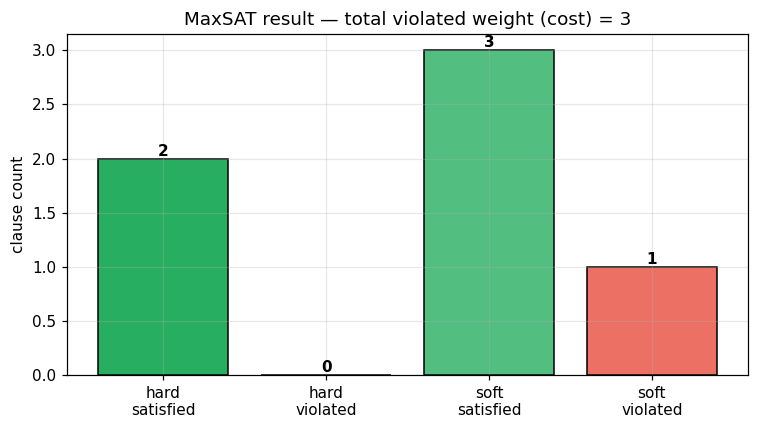

In [12]:
# Visualise the hard/soft satisfaction at the returned assignment
labels = ["hard\nsatisfied", "hard\nviolated", "soft\nsatisfied", "soft\nviolated"]
vals = [mres.n_hard_sat, mres.n_hard_total - mres.n_hard_sat,
        mres.n_soft_sat, mres.n_soft_total - mres.n_soft_sat]
colors = ["#27ae60", "#c0392b", "#52be80", "#ec7063"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, vals, color=colors, edgecolor="black")
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), str(int(v)),
             ha="center", va="bottom", fontweight="bold")
plt.title(f"MaxSAT result — total violated weight (cost) = {mres.cost:g}")
plt.ylabel("clause count")
plt.tight_layout(); plt.show()

## Summary

* `solve_sat_file` / `solve_maxsat_file` are the one-line entry points; both return a rich
  `SolveResult`.
* `SolverConfig` exposes the fast (β) and slow (c) schedules plus chain/step budgets.
* The `history_*` arrays make convergence **observable** — schedules, free energy, and the
  satisfied-clause curve.
* `CNLMLangevinSolver(instance, config).solve()` is the object API for reuse and sweeps.
* MaxSAT works identically and reports hard/soft satisfaction and the violated-weight cost.

**Next:** `02_hobo_reducers.ipynb` — turning high-degree objectives into QUBO form.